# Factor attribution plots

## 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MaxNLocator

# paths, adjust if the files sit elsewhere
data_dir = Path('../results/transformer/analysis')
plots_dir = Path('../plots/factor_plots')
plots_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(
    context='paper',
    style='whitegrid',
    font='serif',
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#333333',
        'axes.labelcolor': '#222222',
        'axes.titleweight': 'bold',
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'xtick.labelsize': 8.5,
        'ytick.labelsize': 8.5,
        'legend.fontsize': 8,
        'legend.title_fontsize': 8.5,
        'grid.color': '#E6E6E6',
        'grid.linewidth': 0.6,
        'savefig.dpi': 300,
    },
)


def pretty_label(text):
    return str(text).replace('_', ' ').replace('short term', 'short-term').title()


def pretty_variant(text):
    return str(text).replace('_', ' ').replace('per feature', 'per-feature').title()


def style_axis(ax, grid_axis='y'):
    ax.grid(True, axis=grid_axis, color='#E6E6E6', linewidth=0.6)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(plots_dir / f'{name}.png', dpi=300, bbox_inches='tight')
plt.rcParams['font.serif'] = ['TeX Gyre Termes', 'Liberation Serif', 'Times New Roman', 'DejaVu Serif']


## 2. Load the saved data and apply factor categories

In [2]:
with open(data_dir / 'analysis_metadata.json') as f:
    meta = json.load(f)

jkp_theme_map = meta['jkp_theme_map']
variants = meta['variants']
n_test_months = meta.get('n_test_months')
print('variants:', variants)
print('test months:', n_test_months)


def add_theme(df, char_col='characteristic'):
    df = df.copy()
    df['theme'] = df[char_col].map(lambda c: jkp_theme_map.get(c, 'other'))
    return df


path1_df = add_theme(pd.read_csv(data_dir / 'path1_characteristic_weights.csv'))
grad_df = add_theme(pd.read_csv(data_dir / 'longonly_gradient_attribution.csv'))

print()
print('path1', path1_df.shape, 'columns', list(path1_df.columns))
print('grad ', grad_df.shape, 'columns', list(grad_df.columns))

n_other = (path1_df.drop_duplicates('characteristic')['theme'] == 'other').sum()
n_total = path1_df['characteristic'].nunique()
print()
print(f'note, {n_other} of {n_total} retained characteristics fall in the unassigned')
print('Other Factors list, so the "other" bucket is large by construction. the')
print('individual characteristic charts below are the more granular view.')

variants: ['fourier', 'linear', 'per_feature', 'periodic', 'ple']
test months: 60

path1 (760, 5) columns ['variant', 'block', 'characteristic', 'mean_weight', 'theme']
grad  (760, 4) columns ['variant', 'characteristic', 'mean_abs_grad', 'theme']

note, 86 of 152 retained characteristics are in the unthemed
Other Factors list, so the "other" bucket is large by construction. the
individual characteristic charts below are the more granular view.


In [ ]:
all_themes = sorted(set(path1_df['theme']) | set(grad_df['theme']))
named_themes = [t for t in all_themes if t != 'other']
palette = sns.husl_palette(len(named_themes), s=0.45, l=0.52)
theme_color = dict(zip(named_themes, palette))
theme_color['other'] = '#9c9c9c'
print('themes:', all_themes)

themes: ['debt_issuance', 'investment', 'low_leverage', 'low_risk', 'momentum', 'other', 'profit_growth', 'profitability', 'quality', 'seasonality', 'short_term_reversal', 'size', 'value']


## 3. Path 1 attention, which characteristics the scoring path relies on

`mean_weight` is the average softmax weight path 1 places on each characteristic when building a firm token, after the missingness penalty, averaged across firms, months, and seeds. Weights are on a per block simplex, k0 weights sum to one across k0 characteristics and likewise for k1.

In [4]:
# path 1 attention: theme shares per variant
theme_share = path1_df.groupby(['variant', 'theme'])['mean_weight'].sum().reset_index()
theme_share['share'] = theme_share.groupby('variant')['mean_weight'].transform(lambda s: s / s.sum())
theme_pivot = theme_share.pivot(index='theme', columns='variant', values='share').fillna(0.0)
theme_pivot['mean'] = theme_pivot.mean(axis=1)
theme_pivot = theme_pivot.sort_values('mean', ascending=False)
print('share of path 1 characteristic attention by factor category')
print(theme_pivot.round(4).to_string())

share of path 1 characteristic attention by factor theme
variant              fourier  linear  per_feature  periodic     ple    mean
theme                                                                      
other                 0.4918  0.5224       0.5225    0.5223  0.5175  0.5153
low_risk              0.0787  0.0956       0.0956    0.0957  0.0981  0.0928
value                 0.0873  0.0602       0.0602    0.0602  0.0600  0.0656
momentum              0.0680  0.0550       0.0551    0.0551  0.0527  0.0572
profitability         0.0610  0.0545       0.0545    0.0545  0.0550  0.0559
low_leverage          0.0292  0.0355       0.0354    0.0354  0.0358  0.0343
short_term_reversal   0.0297  0.0350       0.0351    0.0350  0.0344  0.0338
size                  0.0472  0.0278       0.0277    0.0278  0.0328  0.0327
investment            0.0317  0.0302       0.0301    0.0301  0.0311  0.0306
quality               0.0289  0.0311       0.0311    0.0311  0.0306  0.0305
profit_growth         0.0248  0

### 3a. Category composition by variant

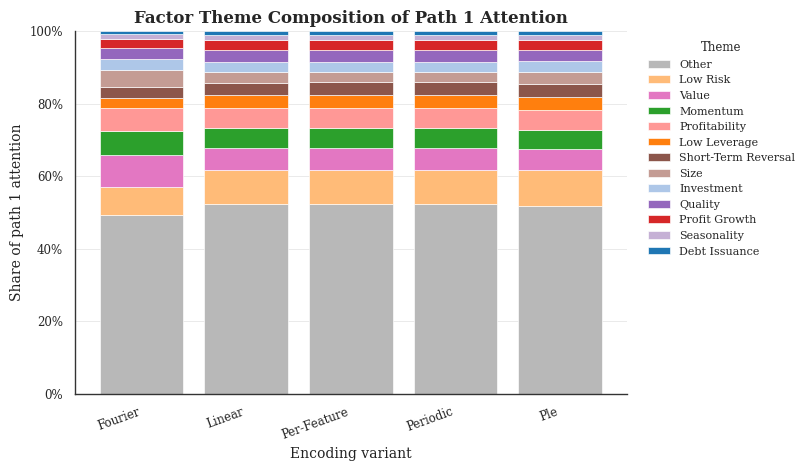

In [5]:
# stacked composition of path 1 attention by variant
fig, ax = plt.subplots(figsize=(8.2, 4.8))
order = theme_pivot.drop(columns='mean').index
x = np.arange(len(variants))
bottom = np.zeros(len(variants))
for theme in order:
    vals = theme_pivot.loc[theme, variants].values.astype(float)
    ax.bar(x, vals, bottom=bottom, label=pretty_label(theme), color=theme_color[theme], edgecolor='white', linewidth=0.45)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels([pretty_variant(v) for v in variants], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Share of path 1 attention')
ax.set_xlabel('Encoding variant')
ax.set_title('Factor Category Composition of Path 1 Attention')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=False)
style_axis(ax)
save_fig(fig, 'path1_theme_composition')
plt.show()

### 3b. Named categories only, on a readable scale

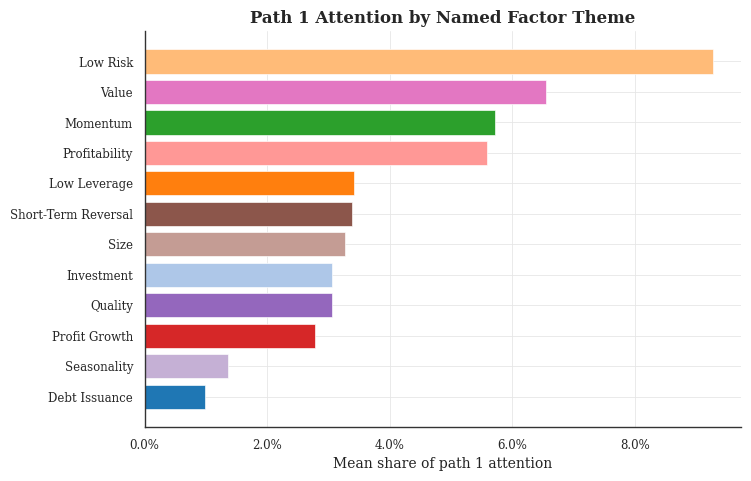

In [6]:
# same but excluding the large unthemed bucket, to compare the named themes on a readable scale
fig, ax = plt.subplots(figsize=(7.6, 4.9))
named = [t for t in order if t != 'other']
sub = theme_pivot.loc[named, 'mean'].sort_values(ascending=True)
ax.barh([pretty_label(t) for t in sub.index], sub.values, color=[theme_color[t] for t in sub.index], edgecolor='white', linewidth=0.45)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('Mean share of path 1 attention')
ax.set_title('Path 1 Attention by Named Factor Category')
style_axis(ax, grid_axis='x')
save_fig(fig, 'path1_named_themes')
plt.show()

### 3c. Top individual characteristics, the granular view

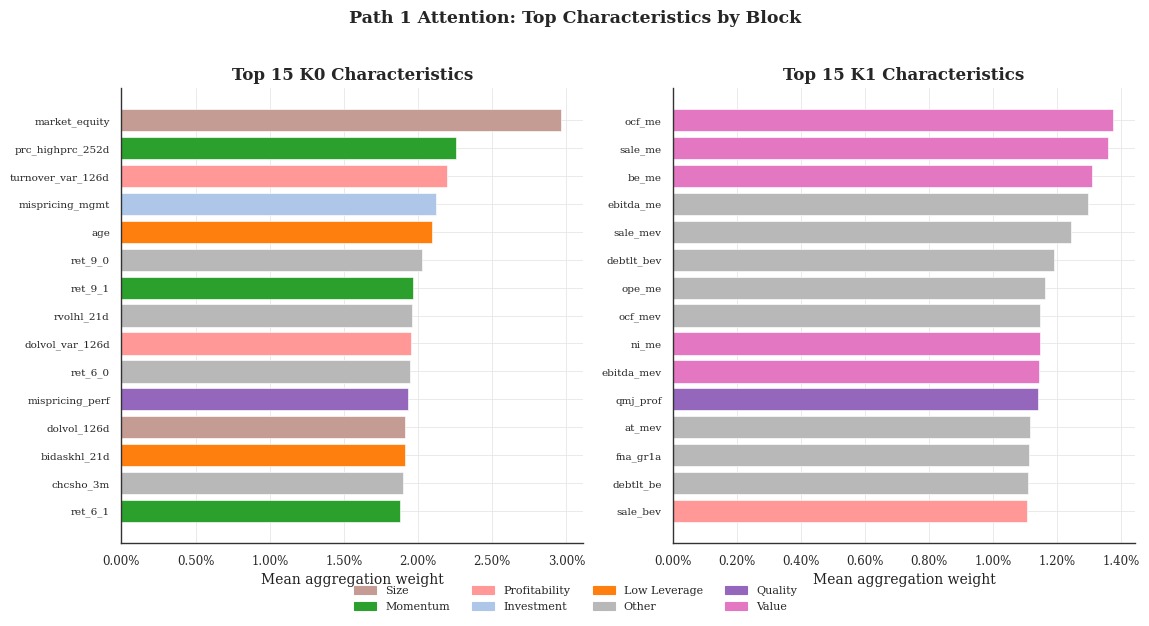

In [7]:
# top individual characteristics by path 1 attention weight, per block, averaged over variants
fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.8))
present = []
for ax, block in zip(axes, ['k0', 'k1']):
    sub = path1_df[path1_df['block'] == block]
    top = sub.groupby(['characteristic', 'theme'])['mean_weight'].mean().sort_values(ascending=False).head(15)
    chars = [c for c, _ in top.index][::-1]
    themes = [t for _, t in top.index][::-1]
    present.extend(themes[::-1])
    ax.barh(chars, top.values[::-1], color=[theme_color[t] for t in themes], edgecolor='white', linewidth=0.45)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(f'Top 15 {block.upper()} Characteristics')
    ax.set_xlabel('Mean aggregation weight')
    ax.tick_params(axis='y', labelsize=7.5)
    style_axis(ax, grid_axis='x')
handles = [mpl.patches.Patch(color=theme_color[t], label=pretty_label(t)) for t in dict.fromkeys(present)]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.035))
fig.suptitle('Path 1 Attention: Top Characteristics by Block', fontsize=12.5, fontweight='bold', y=1.02)
save_fig(fig, 'path1_top_characteristics')
plt.show()

## 4. Long only gradient attribution, which characteristics move the book

`mean_abs_grad` is the mean absolute gradient of the book weighted combined score with respect to each raw characteristic, capturing both paths at once, on the firms that actually enter the long book.

In [8]:
# long only gradient attribution: theme shares per variant
grad_theme = grad_df.groupby(['variant', 'theme'])['mean_abs_grad'].sum().reset_index()
grad_theme['share'] = grad_theme.groupby('variant')['mean_abs_grad'].transform(lambda s: s / s.sum())
grad_pivot = grad_theme.pivot(index='theme', columns='variant', values='share').fillna(0.0)
grad_pivot['mean'] = grad_pivot.mean(axis=1)
grad_pivot = grad_pivot.sort_values('mean', ascending=False)
print('share of long only book gradient attribution by factor category')
print(grad_pivot.round(4).to_string())

share of long only book gradient attribution by factor theme
variant              fourier  linear  per_feature  periodic     ple    mean
theme                                                                      
other                 0.5564  0.5535       0.5380    0.5569  0.5523  0.5514
value                 0.1072  0.0906       0.1072    0.1169  0.0885  0.1021
low_risk              0.0500  0.0609       0.0468    0.0422  0.0673  0.0534
profitability         0.0382  0.0476       0.0519    0.0450  0.0434  0.0452
quality               0.0295  0.0424       0.0695    0.0391  0.0364  0.0434
size                  0.0477  0.0262       0.0322    0.0370  0.0361  0.0358
momentum              0.0297  0.0308       0.0311    0.0344  0.0442  0.0340
low_leverage          0.0296  0.0323       0.0259    0.0436  0.0314  0.0326
investment            0.0317  0.0368       0.0214    0.0268  0.0274  0.0288
profit_growth         0.0259  0.0264       0.0202    0.0137  0.0290  0.0230
short_term_reversal   0.024

### 4a. Category composition by variant

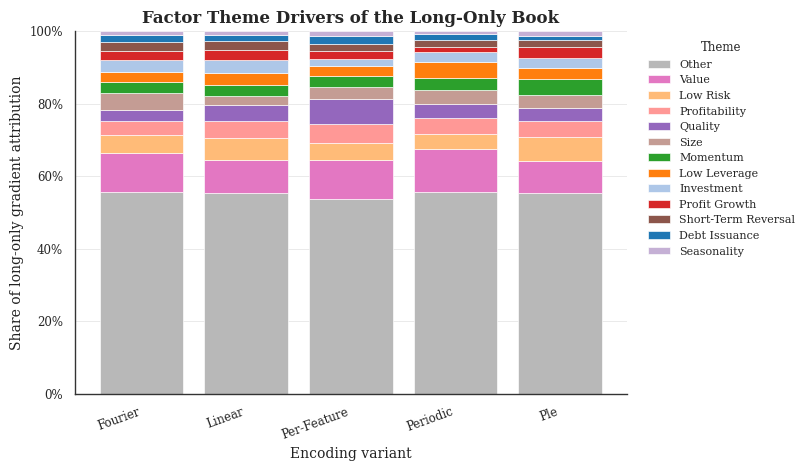

In [9]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
order_g = grad_pivot.drop(columns='mean').index
x = np.arange(len(variants))
bottom = np.zeros(len(variants))
for theme in order_g:
    vals = grad_pivot.loc[theme, variants].values.astype(float)
    ax.bar(x, vals, bottom=bottom, label=pretty_label(theme), color=theme_color[theme], edgecolor='white', linewidth=0.45)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels([pretty_variant(v) for v in variants], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Share of long-only gradient attribution')
ax.set_xlabel('Encoding variant')
ax.set_title('Factor Category Drivers of the Long-Only Book')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=False)
style_axis(ax)
save_fig(fig, 'longonly_theme_composition')
plt.show()

### 4b. Top individual characteristics driving the book

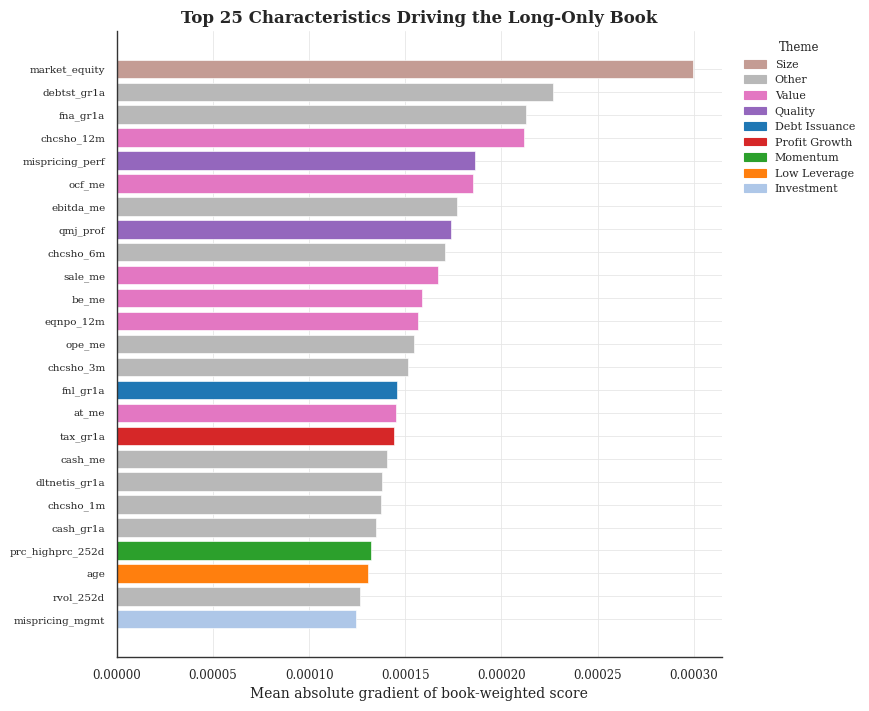

In [10]:
# top individual characteristics driving the long only book, averaged over variants
fig, ax = plt.subplots(figsize=(8.8, 7.2))
top = grad_df.groupby(['characteristic', 'theme'])['mean_abs_grad'].mean().sort_values(ascending=False).head(25)
chars = [c for c, _ in top.index][::-1]
themes = [t for _, t in top.index][::-1]
ax.barh(chars, top.values[::-1], color=[theme_color[t] for t in themes], edgecolor='white', linewidth=0.45)
ax.set_title('Top 25 Characteristics Driving the Long-Only Book')
ax.set_xlabel('Mean absolute gradient of book-weighted score')
ax.tick_params(axis='y', labelsize=7.5)
style_axis(ax, grid_axis='x')
present = list(dict.fromkeys(themes[::-1]))
handles = [mpl.patches.Patch(color=theme_color[t], label=pretty_label(t)) for t in present]
ax.legend(handles=handles, title='Category', bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=False)
save_fig(fig, 'longonly_top_characteristics')
plt.show()

## 5. Comparison, where path 2 shifts the factor emphasis

Path 1's attention says what the scoring path attends to. The long only gradient says what actually moves the book once both paths combine. The difference between the two, per category, is where path 2 changes the emphasis.

In [ ]:
compare = pd.DataFrame({
    'path1_attention_share': theme_pivot['mean'],
    'longonly_gradient_share': grad_pivot['mean'],
}).fillna(0.0)
compare['difference'] = compare['longonly_gradient_share'] - compare['path1_attention_share']
compare = compare.sort_values('longonly_gradient_share', ascending=False)
print('factor category, path 1 attention vs long only gradient share')
print(compare.round(4).to_string())
compare.to_csv(data_dir / 'factor_theme_comparison.csv')

factor theme, path 1 attention vs long only gradient share
                     path1_attention_share  longonly_gradient_share  difference
theme                                                                          
other                               0.5153                   0.5514      0.0361
value                               0.0656                   0.1021      0.0365
low_risk                            0.0928                   0.0534     -0.0393
profitability                       0.0559                   0.0452     -0.0107
quality                             0.0305                   0.0434      0.0128
size                                0.0327                   0.0358      0.0032
momentum                            0.0572                   0.0340     -0.0231
low_leverage                        0.0343                   0.0326     -0.0017
investment                          0.0306                   0.0288     -0.0018
profit_growth                       0.0279                   

### 5a. Side by side shares

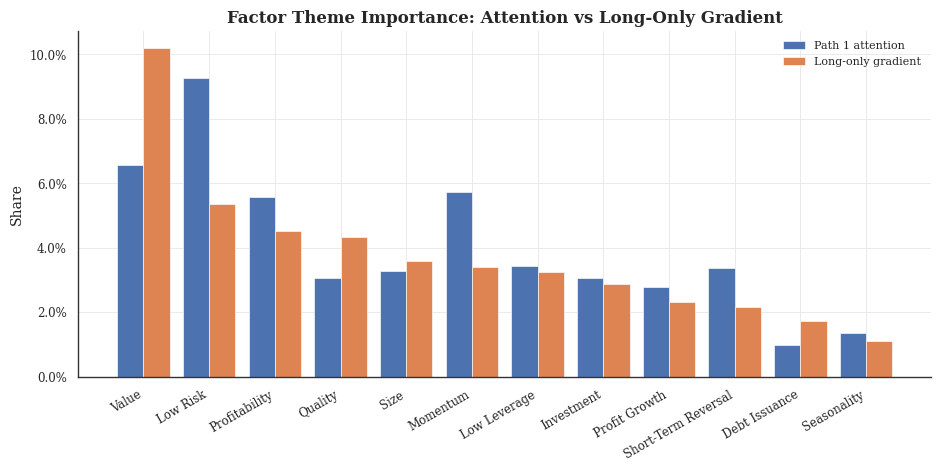

In [ ]:
# grouped bars, named themes only for readability
fig, ax = plt.subplots(figsize=(9.5, 4.8))
named = compare.drop(index='other', errors='ignore')
x = np.arange(len(named))
bar_colors = ['#3060c0', '#c17563']
ax.bar(x - 0.2, named['path1_attention_share'], 0.4, label='Path 1 attention', color=bar_colors[0], edgecolor='white', linewidth=0.45)
ax.bar(x + 0.2, named['longonly_gradient_share'], 0.4, label='Long-only gradient', color=bar_colors[1], edgecolor='white', linewidth=0.45)
ax.set_xticks(x)
ax.set_xticklabels([pretty_label(t) for t in named.index], rotation=30, ha='right')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Share')
ax.set_title('Factor Category Importance: Attention vs Long-Only Gradient')
ax.legend(frameon=False, loc='upper right')
style_axis(ax)
save_fig(fig, 'factor_theme_comparison')
plt.show()

### 5b. The shift itself

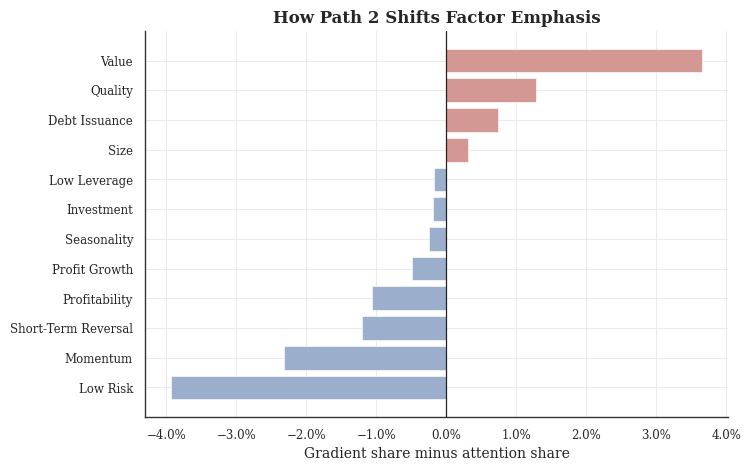

In [ ]:
# the shift itself, sorted. bars to the right are themes path 2 amplifies in the book.
fig, ax = plt.subplots(figsize=(7.6, 4.8))
diff = compare.drop(index='other', errors='ignore')['difference'].sort_values()
colors = ['#c17563' if v < 0 else '#3060c0' for v in diff.values]
ax.barh([pretty_label(t) for t in diff.index], diff.values, color=colors, edgecolor='white', linewidth=0.45)
ax.axvline(0, color='#222222', linewidth=0.9)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('Gradient share minus attention share')
ax.set_title('How Path 2 Shifts Factor Emphasis')
style_axis(ax, grid_axis='x')
save_fig(fig, 'factor_theme_shift')
plt.show()

## 6. Variant agreement

How stable is each factor category's importance across the five encoder variants. Since path 1 differs only by its encoder, close agreement across variants indicates the attention pattern is a property of the data rather than of a particular encoder choice.

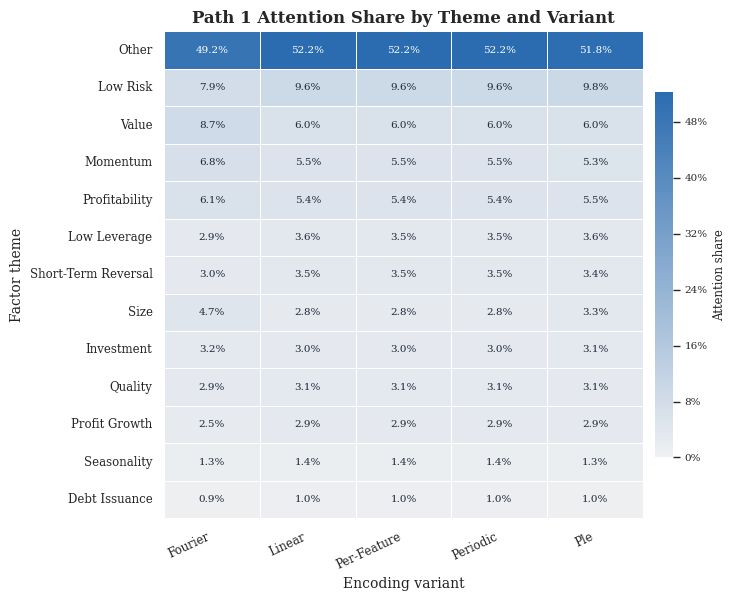

In [14]:
# how consistent is each theme's importance across the five encoder variants?
fig, ax = plt.subplots(figsize=(7.6, 6.1))
hm = theme_pivot[variants]
annot = hm.map(lambda v: f'{v:.1%}') if hasattr(hm, 'map') else hm.applymap(lambda v: f'{v:.1%}')
# the exact institutional blue used throughout the dissertation's other
# figures, rather than a close but different blue
cmap = sns.light_palette('#3060c0', as_cmap=True)
heat = sns.heatmap(hm, ax=ax, cmap=cmap, vmin=0, vmax=hm.values.max(), annot=annot, fmt='', linewidths=0.45, linecolor='white', annot_kws={'fontsize': 7.5}, cbar_kws={'label': 'Attention share', 'shrink': 0.75, 'pad': 0.02})
threshold = hm.values.max() * 0.55
for text, value in zip(ax.texts, hm.to_numpy().ravel()):
    text.set_color('white' if value > threshold else '#1F2937')
ax.set_xticklabels([pretty_variant(v) for v in variants], rotation=25, ha='right')
ax.set_yticklabels([pretty_label(t) for t in hm.index], rotation=0)
ax.set_xlabel('Encoding variant')
ax.set_ylabel('Factor category')
ax.set_title('Path 1 Attention Share by Category and Variant')
cbar = heat.collections[0].colorbar
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1))
cbar.ax.tick_params(labelsize=7.5)
cbar.ax.yaxis.label.set_size(8.5)
save_fig(fig, 'path1_theme_variant_heatmap')
plt.show()